In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import omicverse as ov
#import scvi
#from scvi.model.utils import mde
#from scarches.dataset.trvae.data_handling import remove_sparsity
from scipy import sparse

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

In [2]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (3, 3)

In [3]:
# Change the working directory to the Garfield folder (if needed)
os.chdir('/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251021_fetal_adult_brain_merge_rename_scdevelopment/data')
os.getcwd()

'/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251021_fetal_adult_brain_merge_rename_scdevelopment/data'

In [4]:
adata= sc.read('human_dev.h5ad')

In [5]:
# Load dataset
adata1 = sc.read('All_non-neuronal_cells.h5ad')
adata2 = sc.read('All_neurons.h5ad')

adata2

AnnData object with n_obs × n_vars = 2480956 × 59236
    obs: 'ROIGroup', 'ROIGroupCoarse', 'ROIGroupFine', 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'Biotype', 'Chromosome', 'End', 'Gene', 'Start', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: '

In [5]:
adata.var

,Accession,Chromosome,End,GeneTotalUMIs,Start,Gene
Accession,,,,,,
ENSG00000223972.5,ENSG00000223972.5,chr1,14409,3,11869,DDX11L1
ENSG00000227232.5,ENSG00000227232.5,chr1,29570,104073,14404,WASH7P
ENSG00000278267.1,ENSG00000278267.1,chr1,17436,0,17369,MIR6859-1
ENSG00000284332.1,ENSG00000284332.1,chr1,30503,0,30366,MIR1302-2
ENSG00000268020.3,ENSG00000268020.3,chr1,53312,0,52473,OR4G4P
...,...,...,...,...,...,...
ENSG00000275757.1,ENSG00000275757.1,chr22_KI270733v1,174108,0,173956,5_8S_rRNA-8
ENSG00000278573.1,ENSG00000278573.1,chr22_KI270734v1,60316,0,59711,AC007325.3
ENSG00000276017.1,ENSG00000276017.1,chr22_KI270734v1,74814,15,72411,AC007325.1


In [6]:
def preprocess_gene_names_keep_first(adata):
    """处理基因名，用feature_name替换，对重复基因保留第一个出现的"""
    # 保存原始基因名到新的列
    adata.var['original_gene_id'] = adata.var.index
    
    # 获取feature_name
    feature_names = adata.var['Gene'].values
    
    # 创建临时DataFrame来处理重复基因
    temp_df = pd.DataFrame({
        'Gene': feature_names,
        'original_index': range(len(feature_names))
    })
    
    # 找出第一个出现的唯一基因
    unique_indices = temp_df.drop_duplicates(subset='Gene', keep='first').index
    
    # 筛选出唯一的基因
    adata_unique = adata[:, unique_indices].copy()
    
    # 设置新的索引为feature_name
    adata_unique.var.index = adata_unique.var['Gene'].values
    
    print(f"原始基因数: {adata.n_vars}")
    print(f"去重后基因数: {adata_unique.n_vars}")
    print(f"移除的重复基因数: {adata.n_vars - adata_unique.n_vars}")
    
    return adata_unique
adata = preprocess_gene_names_keep_first(adata)

原始基因数: 59459
去重后基因数: 59459
移除的重复基因数: 0


In [6]:
def preprocess_gene_names_keep_first(adata):
    """处理基因名，用feature_name替换，对重复基因保留第一个出现的"""
    # 保存原始基因名到新的列
    adata.var['original_gene_id'] = adata.var.index
    
    # 获取feature_name
    feature_names = adata.var['feature_name'].values
    
    # 创建临时DataFrame来处理重复基因
    temp_df = pd.DataFrame({
        'feature_name': feature_names,
        'original_index': range(len(feature_names))
    })
    
    # 找出第一个出现的唯一基因
    unique_indices = temp_df.drop_duplicates(subset='feature_name', keep='first').index
    
    # 筛选出唯一的基因
    adata_unique = adata[:, unique_indices].copy()
    
    # 设置新的索引为feature_name
    adata_unique.var.index = adata_unique.var['feature_name'].values
    
    print(f"原始基因数: {adata.n_vars}")
    print(f"去重后基因数: {adata_unique.n_vars}")
    print(f"移除的重复基因数: {adata.n_vars - adata_unique.n_vars}")
    
    return adata_unique

# 处理第一个数据集
print("处理 adata1...")
adata1 = preprocess_gene_names_keep_first(adata1)

# 处理第二个数据集
print("\n处理 adata2...")
adata2 = preprocess_gene_names_keep_first(adata2)

处理 adata1...
原始基因数: 59236
去重后基因数: 58032
移除的重复基因数: 1204

处理 adata2...
原始基因数: 59236
去重后基因数: 58032
移除的重复基因数: 1204


In [7]:
import scanpy as sc
import anndata as ad

# 合并数据
combined_adata = ad.concat(
    {"non-neuronal": adata1, "All_neurons": adata2},
    label="batch",  # 添加批次信息列
    join="inner"  # 保留共有的基因
)

print(f"合并后的数据形状: {combined_adata.shape}")

合并后的数据形状: (3369219, 58032)


In [8]:
combined_adata.obsm['X_umap']=combined_adata.obsm['X_UMAP']

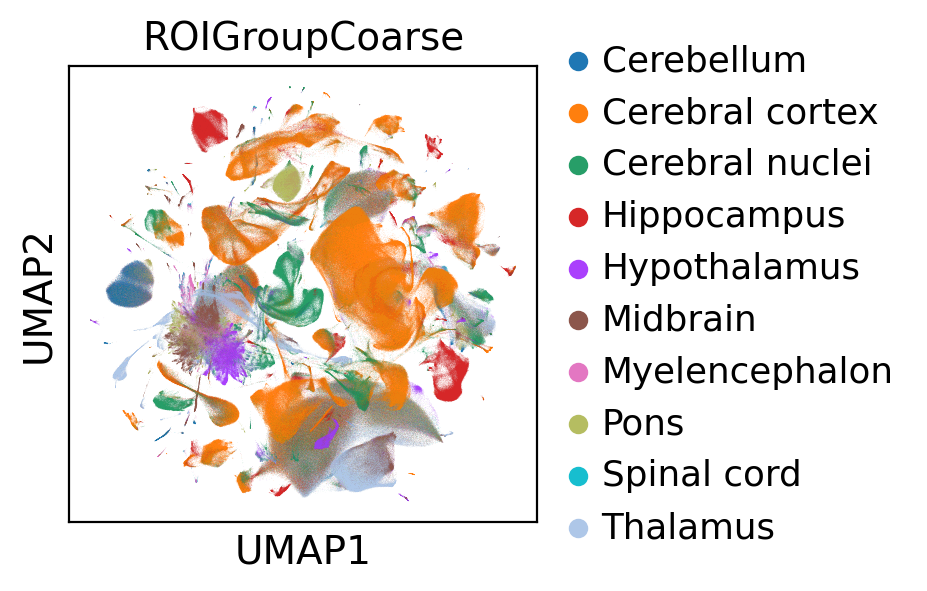

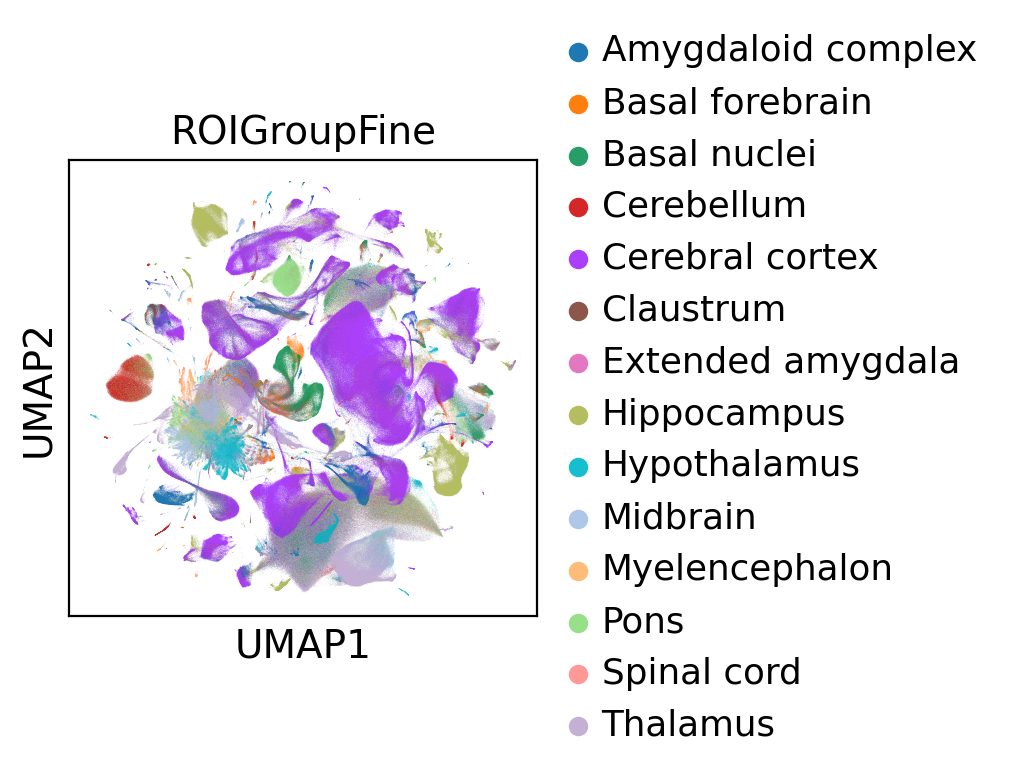

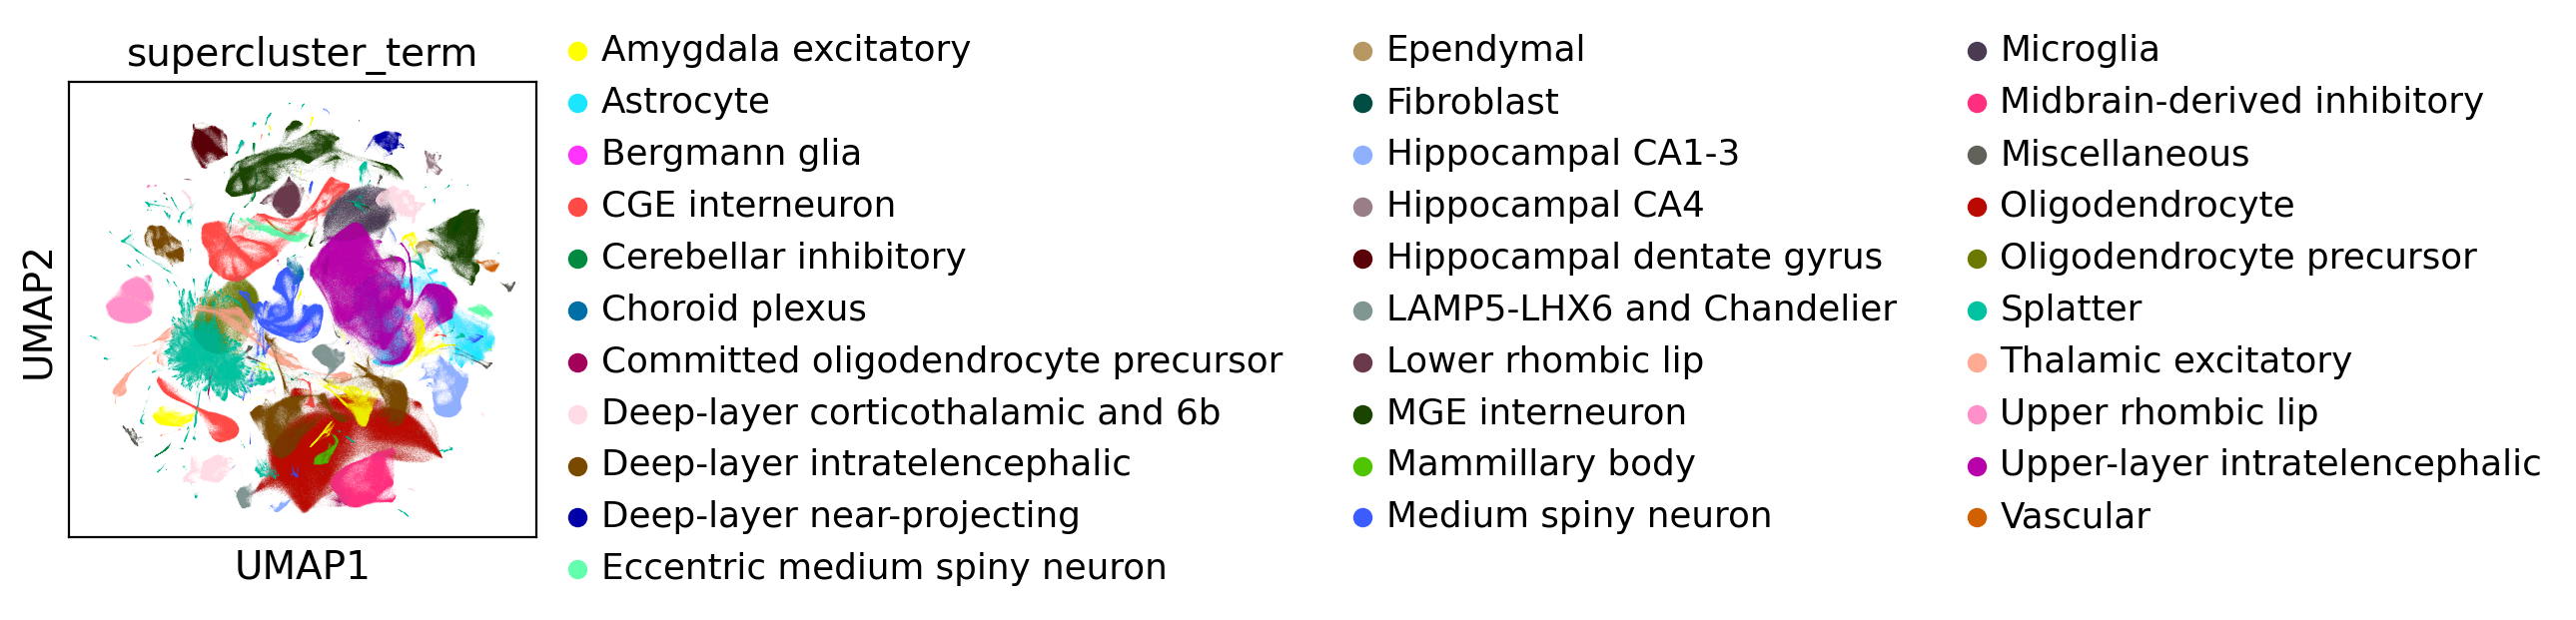

In [42]:
sc.pl.umap(combined_adata,color='ROIGroupCoarse')
sc.pl.umap(combined_adata,color='ROIGroupFine')
sc.pl.umap(combined_adata,color='supercluster_term')

In [9]:
combined_adata

AnnData object with n_obs × n_vars = 3369219 × 58032
    obs: 'ROIGroup', 'ROIGroupCoarse', 'ROIGroupFine', 'roi', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'dissection', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'supercluster_term', 'cluster_id', 'subcluster_id', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'batch'
    obsm: 'X_UMAP', 'X_tSNE', 'X_umap'

In [10]:
# Rename the columns in preimplantation_adata.obs
combined_adata.obs.rename(
    columns={
        "development_stage": "stage",
        "total_UMIs": "nCount_RNA",
        "total_genes": "nFeature_RNA",
        "ROIGroupCoarse": "orig_anno",
        "ROIGroupFine": "orig_sub_anno",
        "dissection": "sample",
        "fraction_mitochondrial": "percent.mt",
        "supercluster_term": "reanno"
        #"technology": "platform",
        #"experiment": "orig.ident"
    },
    inplace=True
)

# Verify the renamed columns
print("Renamed columns in adata.obs:")
print(combined_adata.obs.columns)

# Optionally inspect the first few rows of the updated .obs DataFrame
print("\nFirst few rows of updated .obs:")
print(combined_adata.obs.head())
combined_adata.obs["orig.ident"] = "Kimberly Siletti"
combined_adata.obs["orig.ident"] = combined_adata.obs["orig.ident"].astype("category")
combined_adata.obs["lineage"] = "unknown"
combined_adata.obs["lineage"] = combined_adata.obs["orig.ident"].astype("category")

Renamed columns in adata.obs:
Index(['ROIGroup', 'orig_anno', 'orig_sub_anno', 'roi',
       'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id',
       'assay_ontology_term_id', 'sex_ontology_term_id',
       'development_stage_ontology_term_id', 'donor_id', 'suspension_type',
       'sample', 'percent.mt', 'fraction_unspliced', 'cell_cycle_score',
       'nFeature_RNA', 'nCount_RNA', 'sample_id', 'reanno', 'cluster_id',
       'subcluster_id', 'cell_type_ontology_term_id',
       'tissue_ontology_term_id', 'is_primary_data', 'tissue_type',
       'cell_type', 'assay', 'disease', 'sex', 'tissue',
       'self_reported_ethnicity', 'stage', 'observation_joinid', 'batch'],
      dtype='object')

First few rows of updated .obs:
                               ROIGroup     orig_anno orig_sub_anno       roi  \
CellID                                                                          
10X362_3:TCAGTGAGTATTGACC  Hypothalamus  Hypothalamus  Hypothalamus  Human MN   
10X

In [13]:
# 定义要保留的列
columns_to_keep = [
    "stage", "nCount_RNA", "nFeature_RNA", "orig_anno", 
    "orig_sub_anno", "sample", "percent.mt", "reanno", 
    "orig.ident", "lineage"
]

# 检查哪些列实际存在于数据中
existing_columns = [col for col in columns_to_keep if col in combined_adata.obs.columns]
missing_columns = [col for col in columns_to_keep if col not in combined_adata.obs.columns]

print("存在的列:", existing_columns)
print("不存在的列:", missing_columns)

combined_adata=combined_adata.copy()
# 只保留存在的列
combined_adata.obs = combined_adata.obs[existing_columns]

print(f"筛选后的obs列: {list(combined_adata.obs.columns)}")
print(f"obs形状: {combined_adata.obs.shape}")

存在的列: ['stage', 'nCount_RNA', 'nFeature_RNA', 'orig_anno', 'orig_sub_anno', 'sample', 'percent.mt', 'reanno', 'orig.ident', 'lineage']
不存在的列: []
筛选后的obs列: ['stage', 'nCount_RNA', 'nFeature_RNA', 'orig_anno', 'orig_sub_anno', 'sample', 'percent.mt', 'reanno', 'orig.ident', 'lineage']
obs形状: (3369219, 10)


In [ ]:
combined_adata.var

In [15]:
combined_adata.write_h5ad(filename='human_adult_brain.h5ad')

In [7]:
adata

AnnData object with n_obs × n_vars = 1665937 × 59459
    obs: 'Age', 'CellClass', 'Chemistry', 'Region', 'Subregion', 'organism_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_type', 'dissection', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'cluster_id'
    var: 'Accession', 'Chromosome', 'End', 'GeneTotalUMIs', 'Start', 'Gene', 'original_gene_id'
    uns: 'batch_condition', 'title'
    obsm: 'Factors', 'X_Embedding'
    varm: 'Loadings'

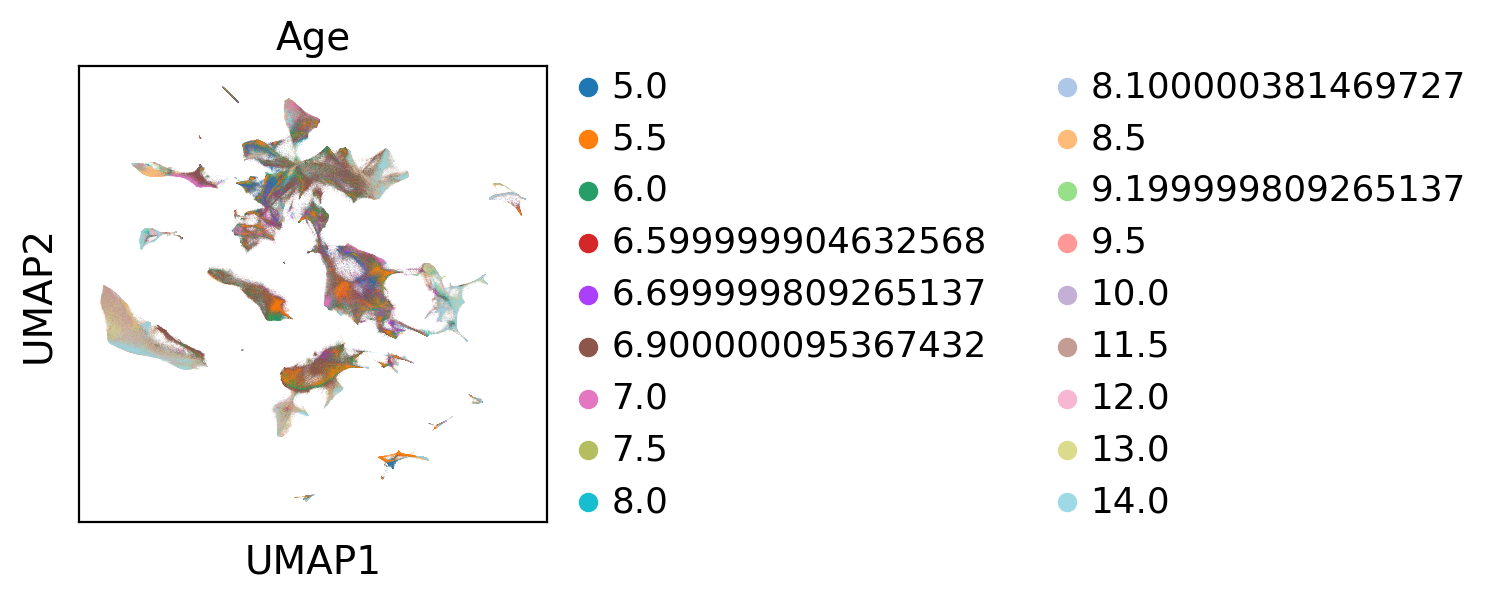

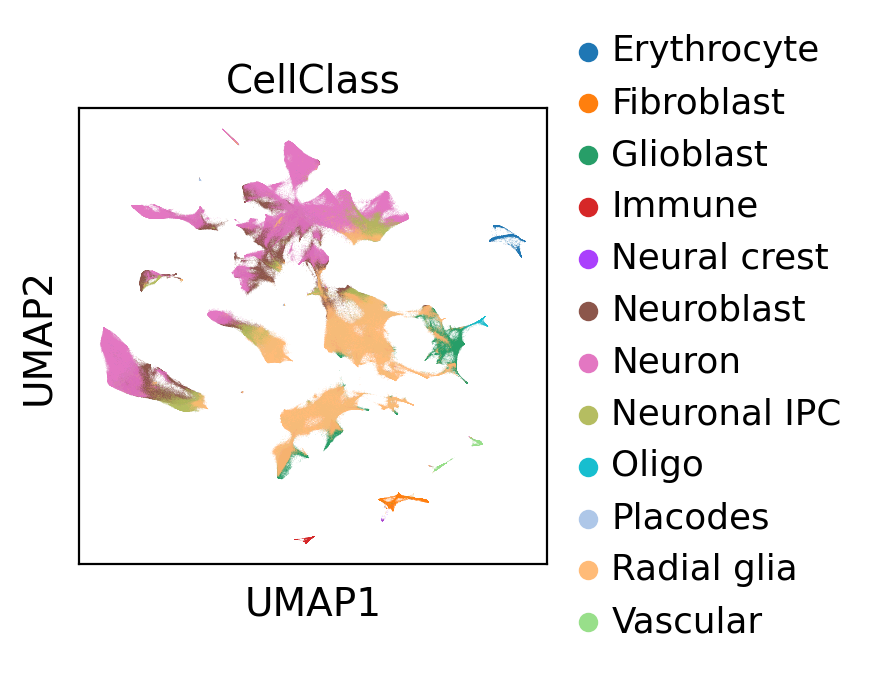

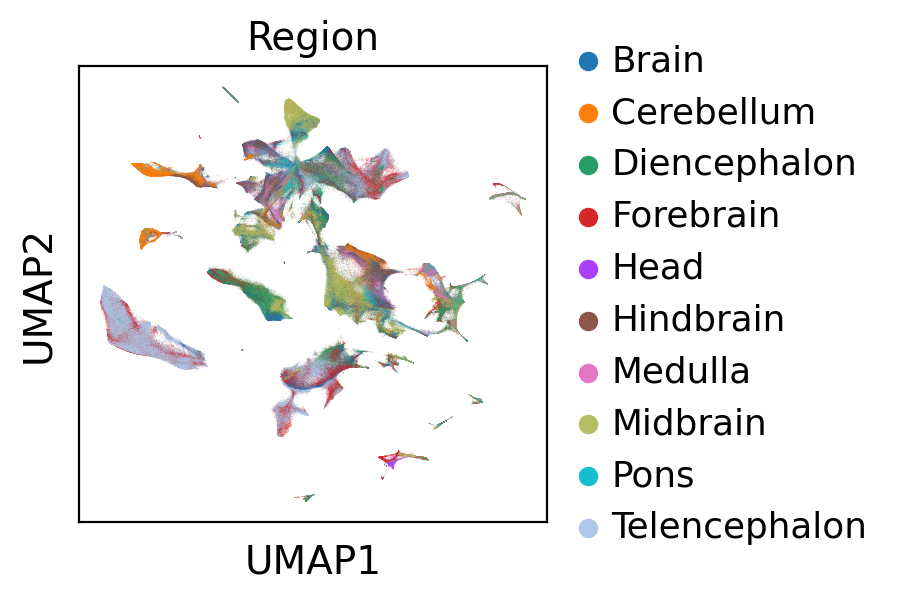

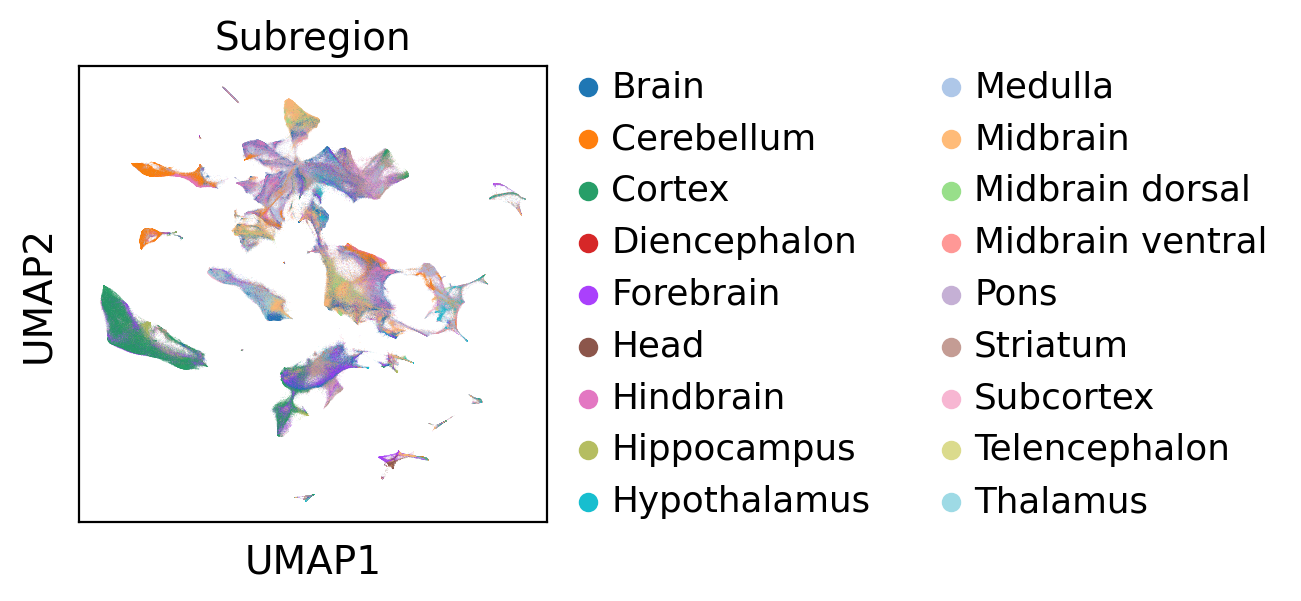

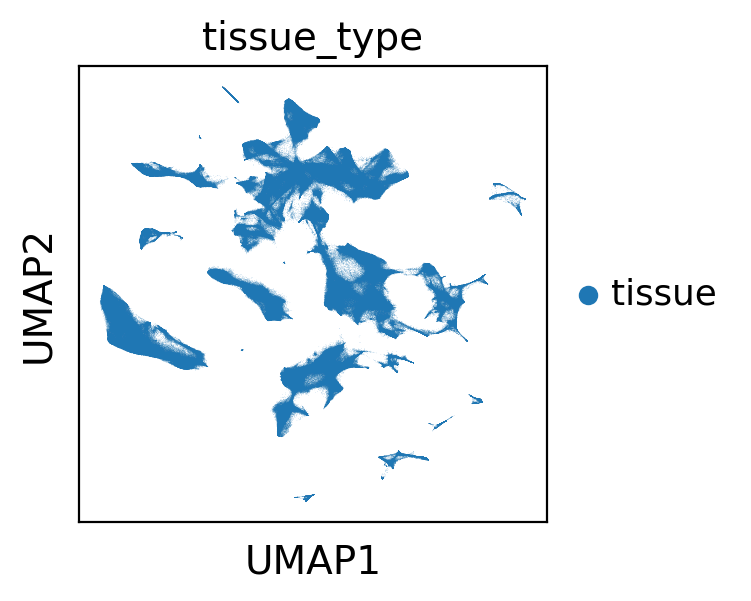

In [8]:
adata.obsm['X_umap'] = adata.obsm['X_Embedding']
sc.pl.umap(adata, color=['Age'])
sc.pl.umap(adata, color=['CellClass'])
sc.pl.umap(adata, color=['Region'])
sc.pl.umap(adata, color=['Subregion'])
sc.pl.umap(adata, color=['tissue_type'])

In [9]:
adata

AnnData object with n_obs × n_vars = 1665937 × 59459
    obs: 'Age', 'CellClass', 'Chemistry', 'Region', 'Subregion', 'organism_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'donor_id', 'suspension_type', 'tissue_type', 'dissection', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score', 'total_genes', 'total_UMIs', 'sample_id', 'cluster_id'
    var: 'Accession', 'Chromosome', 'End', 'GeneTotalUMIs', 'Start', 'Gene', 'original_gene_id'
    uns: 'batch_condition', 'title', 'Age_colors', 'CellClass_colors', 'Region_colors', 'Subregion_colors', 'tissue_type_colors'
    obsm: 'Factors', 'X_Embedding', 'X_umap'
    varm: 'Loadings'

In [10]:
# Rename the columns in preimplantation_adata.obs
fetal.obs.rename(
    columns={
        "Age": "stage",
        "total_UMIs": "nCount_RNA",
        "total_genes": "nFeature_RNA",
        "Region": "orig_anno",
        "Subregion": "orig_sub_anno",
        "donor_id": "sample",
        "fraction_mitochondrial": "percent.mt",
        "CellClass": "lineage"
        #"technology": "platform",
        #"experiment": "orig.ident"
    },
    inplace=True
)

# Verify the renamed columns
print("Renamed columns in adata.obs:")
print(fetal.obs.columns)

# Optionally inspect the first few rows of the updated .obs DataFrame
print("\nFirst few rows of updated .obs:")
print(fetal.obs.head())
#add other keys
fetal.obs["orig.ident"] = "Braun"
fetal.obs["orig.ident"] = fetal.obs["orig.ident"].astype("category")

#change "stage" str type
fetal.obs["stage"] = fetal.obs["stage"].astype("category")
# 定义要保留的列
columns_to_keep = [
    "stage", "nCount_RNA", "nFeature_RNA", "orig_anno", 
    "orig_sub_anno", "sample", "percent.mt",
    "orig.ident", "lineage"
]

# 检查哪些列实际存在于数据中
existing_columns = [col for col in columns_to_keep if col in fetal.obs.columns]
missing_columns = [col for col in columns_to_keep if col not in fetal.obs.columns]

print("存在的列:", existing_columns)
print("不存在的列:", missing_columns)

fetal=fetal.copy()
# 只保留存在的列
fetal.obs = fetal.obs[existing_columns]

print(f"筛选后的obs列: {list(fetal.obs.columns)}")
print(f"obs形状: {fetal.obs.shape}")

fetal.obs["reanno"]=fetal.obs["lineage"]
fetal.layers["counts"]=fetal.X.copy()


Renamed columns in adata.obs:
Index(['stage', 'reanno', 'Chemistry', 'orig_anno', 'orig_sub_anno',
       'organism_ontology_term_id', 'disease_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id',
       'sex_ontology_term_id', 'development_stage_ontology_term_id', 'sample',
       'suspension_type', 'tissue_type', 'dissection',
       'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'percent.mt',
       'fraction_unspliced', 'cell_cycle_score', 'nFeature_RNA', 'nCount_RNA',
       'sample_id', 'cluster_id'],
      dtype='object')

First few rows of updated .obs:
                         stage       reanno Chemistry      orig_anno  \
CellID                                                                 
10X89_1:AAACGGGAGGCTACGA   8.0  Erythrocyte        v2  Telencephalon   
10X89_1:ACGAGGAAGAGCCTAG   8.0  Erythrocyte        v2  Telencephalon   
10X89_1:ACGCCAGTCGATAGAA   8.0  Erythrocyte        v2  Telencephalon   
10X89_1:CCGGGATCAGA

In [15]:
adata.write_h5ad(filename='/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251106_fetal_adult_merge_name_scdevelopment/data/human_fetal_brain.h5ad')

In [4]:
adata1=sc.read_h5ad("human_fetal_brain.h5ad")
adata2=sc.read_h5ad("human_adult_brain.h5ad")

In [20]:
adata1.var

,Accession,Chromosome,End,GeneTotalUMIs,Start,Gene,original_gene_id
DDX11L1,ENSG00000223972.5,chr1,14409,3,11869,DDX11L1,ENSG00000223972.5
WASH7P,ENSG00000227232.5,chr1,29570,104073,14404,WASH7P,ENSG00000227232.5
MIR6859-1,ENSG00000278267.1,chr1,17436,0,17369,MIR6859-1,ENSG00000278267.1
MIR1302-2,ENSG00000284332.1,chr1,30503,0,30366,MIR1302-2,ENSG00000284332.1
OR4G4P,ENSG00000268020.3,chr1,53312,0,52473,OR4G4P,ENSG00000268020.3
...,...,...,...,...,...,...,...
5_8S_rRNA-8,ENSG00000275757.1,chr22_KI270733v1,174108,0,173956,5_8S_rRNA-8,ENSG00000275757.1
AC007325.3,ENSG00000278573.1,chr22_KI270734v1,60316,0,59711,AC007325.3,ENSG00000278573.1
AC007325.1,ENSG00000276017.1,chr22_KI270734v1,74814,15,72411,AC007325.1,ENSG00000276017.1
U6-29,ENSG00000278625.1,chrUn_KI270744v1,51114,0,51009,U6-29,ENSG00000278625.1


In [5]:
import scanpy as sc
import anndata as ad

# 合并数据
combined_adata = ad.concat(
    {"human_fetal_brain": adata1, "human_adult_brain": adata2},
    label="batch",  # 添加批次信息列
    join="inner" 
)

print(f"合并后的数据形状: {combined_adata.shape}")

合并后的数据形状: (5035156, 37540)


In [6]:
# 专门处理stage列的混合数据类型问题
print("处理stage列的混合数据类型...")

# 查看stage列的具体值
print("stage列的值分布:")
print(combined_adata.obs['stage'].value_counts())

# 方法1: 将所有stage值转换为字符串
combined_adata.obs['stage'] = combined_adata.obs['stage'].astype(str)

# 如果需要保持分类类型，重新转换为分类
combined_adata.obs['stage'] = combined_adata.obs['stage'].astype('category')

print("转换后的stage列:")
print(combined_adata.obs['stage'].dtype)
print("前几个值:", combined_adata.obs['stage'].head().tolist())

处理stage列的混合数据类型...
stage列的值分布:
stage
50-year-old stage    1291931
42-year-old stage    1041682
29-year-old stage     984535
6.9                   424012
8.0                   126560
8.5                   119226
6.0                   108199
11.5                  102960
10.0                   88859
9.2                    86890
6.6                    86853
12.0                   86551
6.7                    79972
14.0                   77780
5.0                    62786
5.5                    59667
60-year-old stage      51071
13.0                   38967
7.5                    38870
8.1                    31473
9.5                    28647
7.0                    17665
Name: count, dtype: int64
转换后的stage列:
category
前几个值: ['8.0', '8.0', '8.0', '8.0', '8.0']


In [7]:
combined_adata.write_h5ad(filename='human_all_brain_inner.h5ad')

In [29]:
combined_adata

AnnData object with n_obs × n_vars = 5035156 × 79951
    obs: 'stage', 'nCount_RNA', 'nFeature_RNA', 'orig_anno', 'orig_sub_anno', 'sample', 'percent.mt', 'reanno', 'orig.ident', 'lineage', 'batch'
    obsm: 'Factors', 'X_Embedding', 'X_umap', 'X_UMAP', 'X_tSNE'